# flow along differential field


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))

from client.config import registry
from client.interface import SlopClient
from client.utils.identity import extract_identity_vector

providers = registry.list()
client = SlopClient(providers[-1])
client.connect()
print(f'Connected to {client.info().gpu_name}')

[REMOTE STDERR] [SERVER] 2026-03-09 16:59:17,004 - INFO - server ready


Connected to NVIDIA GeForce RTX 3090


In [2]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from client.utils.identity import extract_identity_vector, apply_identity

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# setup: get the identity vector and embeddings
# ============================================================

arab_vector = extract_identity_vector(client, "Arab", [
    "walking on the beach",
    "sitting on the beach", 
    "standing on the beach"
])

base_embeds, neg = client.embed("person on the beach")
target_embeds = apply_identity(base_embeds, arab_vector, scale=1.0)

# ============================================================
# flow integration along differential field
# ============================================================

def flow_along_differential(client, base_embeds, target_embeds, neg,
                            initial_latent=None, 
                            num_steps=50, 
                            timestep=500,
                            scale_factor=1.0,
                            step_size=0.1):
    """
    Integrate along the differential field (target_score - base_score).
    
    This is NOT normal diffusion - we're flowing purely in the direction
    of the identity difference, ignoring the base denoising dynamics.
    """
    
    # start from random noise or provided point
    if initial_latent is None:
        current = np.random.randn(1, 4, 64, 64).astype(np.float32)
    else:
        current = initial_latent.copy()
    
    trajectory = [current.copy()]
    
    for step in range(num_steps):
        # probe both fields at current position
        base_score = client.probe_at(current, base_embeds, neg, timestep=timestep)
        target_score = client.probe_at(current, target_embeds, neg, timestep=timestep)
        
        # differential = direction of identity push
        diff = target_score - base_score

        diff * scale_factor
        
        # euler integration
        current = current + step_size * diff
        trajectory.append(current.copy())
        
        magnitude = np.linalg.norm(diff)
        print(f"step {step}: differential magnitude = {magnitude:.4f}")
    
    return np.array(trajectory)


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.40it/s], ?it/s]


In [4]:

# ============================================================
# compare: flow vs normal generation
# ============================================================

print("\n=== COMPARISON ===")
print("generating with normal diffusion for comparison...")

# normal generation with target prompt
result_target = client.sample("Arabs in the city", num_steps=50, batch_size=1)
final_latent_target = result_target.points[-1]  # final latent from normal diffusion
img_target = client.render(final_latent_target)[0]

# normal generation with base prompt  
result_base = client.sample("peoples in the city", num_steps=50, batch_size=1)
final_latent_base = result_base.points[-1]
img_base = client.render(final_latent_base)[0]



=== COMPARISON ===
generating with normal diffusion for comparison...


[REMOTE STDERR] [SERVER] 2026-03-09 16:59:36,954 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
100%|██████████| 50/50 [00:02<00:00, 18.91it/s]it/s]
[REMOTE STDERR] [SERVER] 2026-03-09 16:59:52,682 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
100%|██████████| 50/50 [00:02<00:00, 20.65it/s]it/s]


In [5]:

# ============================================================
# run the flow
# ============================================================

print("flowing along the differential field...")
print("(this is pure identity-driven flow, no denoising)\n")

trajectory = flow_along_differential(
    client, 
    base_embeds, 
    target_embeds, 
    neg,
    num_steps=50,
    timestep=500,  # which diffusion timestep to probe at
    step_size=0.5,   # integration step size
    scale_factor=5,
    initial_latent=final_latent_base
)

print(f"\ntrajectory shape: {trajectory.shape}")


flowing along the differential field...
(this is pure identity-driven flow, no denoising)



[REMOTE STDERR] [SERVER] 2026-03-09 17:00:27,660 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
[REMOTE STDERR] [SERVER] 2026-03-09 17:00:48,882 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


step 0: differential magnitude = 13.9609


[REMOTE STDERR] [SERVER] 2026-03-09 17:01:06,700 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
[REMOTE STDERR] [SERVER] 2026-03-09 17:01:27,470 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


step 1: differential magnitude = 11.7891


...

step 47: differential magnitude = 8.9531


[REMOTE STDERR] [SERVER] 2026-03-09 17:44:47,711 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
[REMOTE STDERR] [SERVER] 2026-03-09 17:45:20,325 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


step 48: differential magnitude = 8.6562


[REMOTE STDERR] [SERVER] 2026-03-09 17:45:43,581 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
[REMOTE STDERR] [SERVER] 2026-03-09 17:46:20,432 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


step 49: differential magnitude = 8.6328

trajectory shape: (51, 2, 4, 64, 64)



rendering 10 snapshots...
  rendered step 0
  rendered step 1
  rendered step 3
  rendered step 5
  rendered step 7
  rendered step 9
  rendered step 20
  rendered step 30
  rendered step 40
  rendered step 49


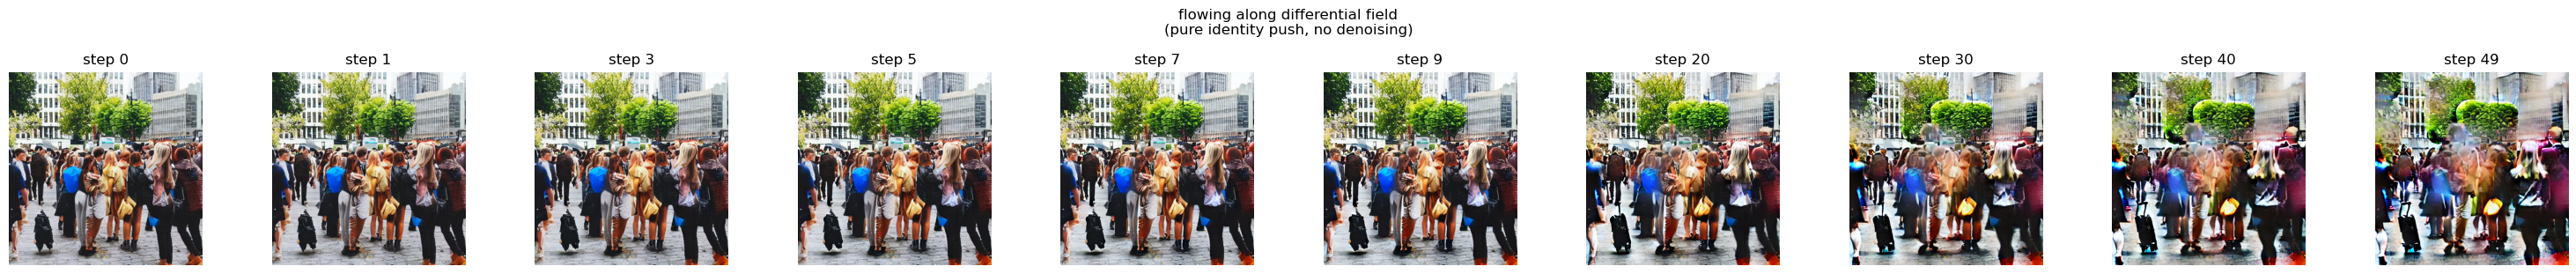

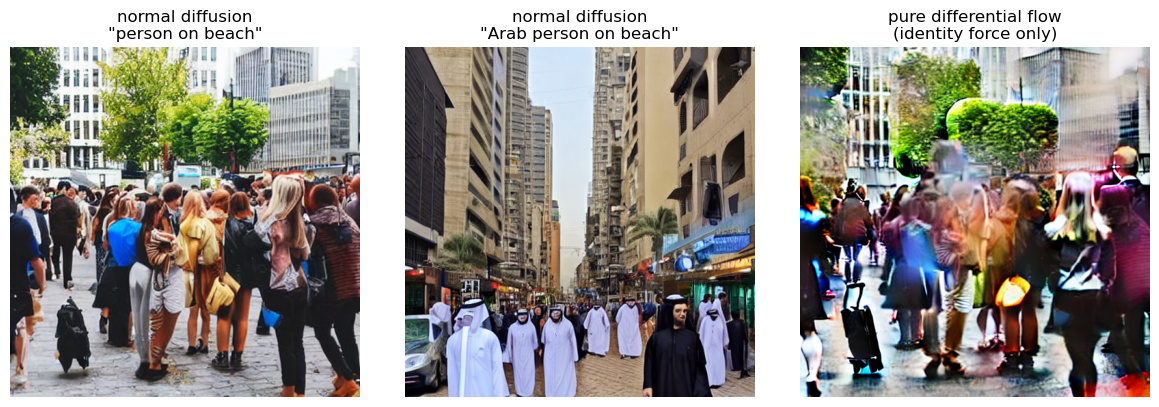

In [6]:

# ============================================================
# render snapshots along the trajectory
# ============================================================

# sample points along trajectory to visualize
indices = [0,1,3,5,7,9,20,30,40,49]
snapshots = trajectory[indices]

print(f"\nrendering {len(indices)} snapshots...")
images = []
for i, latent in enumerate(snapshots):
    img = client.render(latent)[0]
    images.append(img)
    print(f"  rendered step {indices[i]}")

# ============================================================
# visualize
# ============================================================

fig, axes = plt.subplots(1, len(indices), figsize=(3*len(indices), 3))

for i, (img, step_idx) in enumerate(zip(images, indices)):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'step {step_idx}')

plt.suptitle(
    'flowing along differential field\n'
    '(pure identity push, no denoising)', 
    y=1.02
)
plt.tight_layout()
plt.show()

# our flow result
img_flow = images[-1]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_base)
axes[0].axis('off')
axes[0].set_title('normal diffusion\n"person on beach"')

axes[1].imshow(img_target)
axes[1].axis('off')
axes[1].set_title('normal diffusion\n"Arab person on beach"')

axes[2].imshow(img_flow)
axes[2].axis('off')
axes[2].set_title('pure differential flow\n(identity force only)')

plt.tight_layout()
plt.show()